In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"E:\Insigth_Cart\data\cart_insight_supermarket_2025_profit_tax.csv")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4072\683645763.py:4: DtypeWarning: Columns (0: festival_season) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"E:\Insigth_Cart\data\cart_insight_supermarket_2025_profit_tax.csv")


In [ ]:
df.head()

(108802, 53)

In [9]:
df.tail()


,transaction_id,bill_number,date,time,day_name,is_weekend,month,year,festival_season,weather_tag,...,stock_after_sale,reorder_level,low_stock_flag,dead_stock_flag,promotion_type,return_flag,return_reason,basket_size,sales_channel,supplier_id
108797,T20250108798,B20250108798,2025-12-31,09:04:18,Wednesday,0,12,2025,NewYearEve,Pleasant,...,76,120,1,0,none,0,NaN,10,in-store,S006
108798,T20250108799,B20250108799,2025-12-31,13:43:20,Wednesday,0,12,2025,NewYearEve,Cold,...,137,60,0,0,none,0,NaN,10,offline,S013
108799,T20250108800,B20250108800,2025-12-31,21:39:29,Wednesday,0,12,2025,NewYearEve,Cold,...,220,100,0,0,none,0,NaN,13,in-store,S018
108800,T20250108801,B20250108801,2025-12-31,12:34:57,Wednesday,0,12,2025,NewYearEve,Foggy,...,56,70,1,0,none,0,NaN,10,in-store,S008
108801,T20250108802,B20250108802,2025-12-31,13:41:38,Wednesday,0,12,2025,NewYearEve,Cold,...,110,80,0,0,member discount,0,NaN,11,offline,S023


In [10]:
df.shape

(108802, 53)

In [11]:
df.columns

Index(['transaction_id', 'bill_number', 'date', 'time', 'day_name',
       'is_weekend', 'month', 'year', 'festival_season', 'weather_tag',
       'store_name', 'store_city', 'store_state', 'region', 'store_area_type',
       'cashier_id', 'customer_type', 'gender', 'age_group', 'loyalty_member',
       'product_id', 'product_name', 'category', 'subcategory', 'brand',
       'unit_size', 'quantity_sold', 'mrp', 'selling_price', 'discount_amount',
       'discount_percent', 'gross_sales', 'net_sales', 'gst_percent',
       'tax_amount', 'total_bill_amount', 'margin_percent',
       'cost_price_per_unit', 'total_cost', 'profit_amount',
       'profit_margin_percent', 'payment_mode', 'stock_before_sale',
       'stock_after_sale', 'reorder_level', 'low_stock_flag',
       'dead_stock_flag', 'promotion_type', 'return_flag', 'return_reason',
       'basket_size', 'sales_channel', 'supplier_id'],
      dtype='str')

In [18]:
pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.count(),
    'nulls': df.isnull().sum(),
    'duplicate' : df.count() - df.nunique(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(2),
    'unique': df.nunique()
})

,dtype,non_null,nulls,duplicate,null_%,unique
transaction_id,str,108802,0,0,0.00,108802
bill_number,str,108802,0,0,0.00,108802
date,str,108802,0,108437,0.00,365
time,str,108802,0,64610,0.00,44192
day_name,str,108802,0,108795,0.00,7
is_weekend,int64,108802,0,108800,0.00,2
month,int64,108802,0,108790,0.00,12
year,int64,108802,0,108801,0.00,1
festival_season,str,8978,99824,8972,91.75,6
weather_tag,str,108802,0,108793,0.00,9


In [14]:
df.describe()

,is_weekend,month,year,loyalty_member,quantity_sold,mrp,selling_price,discount_amount,discount_percent,gross_sales,...,total_cost,profit_amount,profit_margin_percent,stock_before_sale,stock_after_sale,reorder_level,low_stock_flag,dead_stock_flag,return_flag,basket_size
count,108802.000000,108802.000000,108802.0,108802.000000,108802.000000,108802.000000,108802.000000,108802.000000,108802.000000,108802.000000,...,108802.000000,108802.000000,108802.000000,108802.000000,108802.000000,108802.000000,108802.000000,108802.0,108802.000000,108802.000000
mean,0.356914,6.612195,2025.0,0.398145,4.243819,142.523391,139.742386,11.480997,1.962207,603.512803,...,520.471091,71.560715,13.684959,122.138711,117.894892,71.833284,0.328110,0.0,0.002960,8.120522
std,0.479091,3.405965,0.0,0.489518,3.132832,179.378479,176.491477,75.330040,6.087411,1192.236457,...,1069.357211,116.223694,4.657297,97.846506,97.687172,30.064643,0.469527,0.0,0.054321,4.635272
min,0.000000,1.000000,2025.0,0.000000,1.000000,10.000000,7.000000,0.000000,0.000000,10.000000,...,5.840000,0.920000,2.990000,1.000000,0.000000,10.000000,0.000000,0.0,0.000000,1.000000
25%,0.000000,4.000000,2025.0,0.000000,2.000000,45.000000,42.000000,0.000000,0.000000,135.000000,...,112.520000,16.700000,9.720000,48.000000,44.000000,50.000000,0.000000,0.0,0.000000,5.000000
50%,0.000000,7.000000,2025.0,0.000000,4.000000,75.000000,75.000000,0.000000,0.000000,280.000000,...,244.770000,35.740000,13.430000,99.000000,95.000000,70.000000,0.000000,0.0,0.000000,7.000000
75%,1.000000,10.000000,2025.0,1.000000,6.000000,170.000000,170.000000,0.000000,0.000000,640.000000,...,538.057500,82.647500,17.630000,172.000000,167.000000,90.000000,1.000000,0.0,0.000000,10.000000
max,1.000000,12.000000,2025.0,1.000000,38.000000,1200.000000,1200.000000,6900.000000,50.000000,37200.000000,...,33874.320000,4496.310000,28.810000,800.000000,793.000000,150.000000,1.000000,0.0,1.000000,29.000000


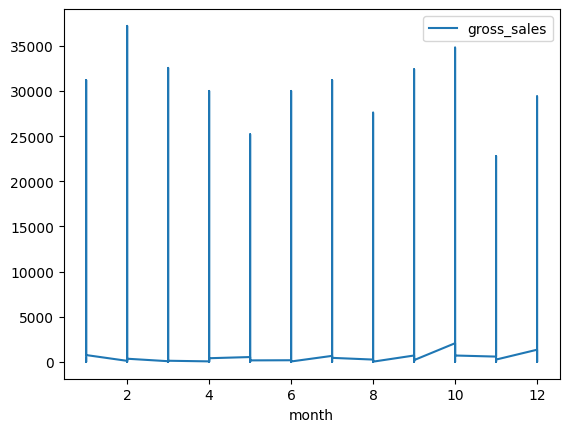

In [5]:
df.plot(kind="line", x="month", y="gross_sales")

plt.show()